In [1]:
import hoda
import tensorly as tl
import mne
!pip install line_profiler
%load_ext line_profiler
mne.set_log_level('ERROR')
tl.get_backend()

  Obtaining dependency information for line_profiler from https://files.pythonhosted.org/packages/43/61/534f034efa3aa01cf3855a37e7d2beee8df39d85e9b1e1302dc011bedcd6/line_profiler-4.1.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.6/717.6 kB 9.6 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 23.2.1 -> 24.0
[notice] To update, run: python3 -m pip install --upgrade pip


'cupy'

In [2]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler

paradigm = P300(resample=48)
dataset = BNCI2014008()


epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[4],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014008 has been renamed to BNCI2014_008. BNCI2014008 will be removed in version 1.1.
The dataset class name 'BNCI2014008' must be an abbreviation of its code 'BNCI2014-008'. See moabb.datasets.base.is_abbrev for more information.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,4,0,0
1,4,0,0
2,4,0,0
3,4,0,0
4,4,0,0
...,...,...,...
4195,4,0,0
4196,4,0,0
4197,4,0,0
4198,4,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

X = epochs.get_data()
y = labels

X.shape

(4200, 8, 48)

In [5]:
from sklearn.model_selection import StratifiedKFold
from hoda.hoda import BTTDA, InfoBTTDA, HODA, trunc_eigh
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler
import  warnings
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.preprocessing import StandardScaler
import warnings

bttda = InfoBTTDA(
    ranks=[None]*4,
    info_crit='bic',
    truncate=True,
    hoda_params=dict(
        max_iter=256,
        tol=1e-12,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=False,
        verbose=True,
        delta=None,
        ortho=False,
        forward=False,
        random_state=42,
       
    ),
    verbose=True,
    extra_train_info=True,
    
    
)
%env PYTHONWARNINGS=ignore
%lprun -f HODA.fit_backward bttda.fit(X,y)

env: PYTHONWARNINGS=ignore
Fitting block 1/4...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

...

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

Timer unit: 1e-09 s

Total time: 11.1354 s
File: /project/src/hoda/hoda.py
Function: fit_backward at line 151

Line #      Hits         Time  Per Hit   % Time  Line Contents
   151                                               def fit_backward(
   152                                                   self, X, y, X_centered=None, means=None, classes=None, class_counts=None
   153                                               ):
   154                                                   # TODO: calculate train info for initialization
   155                                                   # Convert to tensor
   156        16     146279.0   9142.4      0.0          if not tl.is_tensor(X):
   157                                                       X = tl.tensor(X)
   158        16      55691.0   3480.7      0.0          n_samples, *shape = X.shape
   159        16      11920.0    745.0      0.0          order = len(shape)
   160                                           
   161           

In [6]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,bic,mse,F_tr,F_rt
0,1,"(4, 4)",2832.136379,0.914095,0.041657,0.000269
1,2,"(2, 2)",2809.793017,0.901410,0.034437,0.000283
2,3,"(1, 1)",2779.524847,0.897155,0.033703,0.000295
3,4,"(1, 1)",2787.786093,0.895815,0.034448,0.000295


<Axes: xlabel='block', ylabel='bic'>

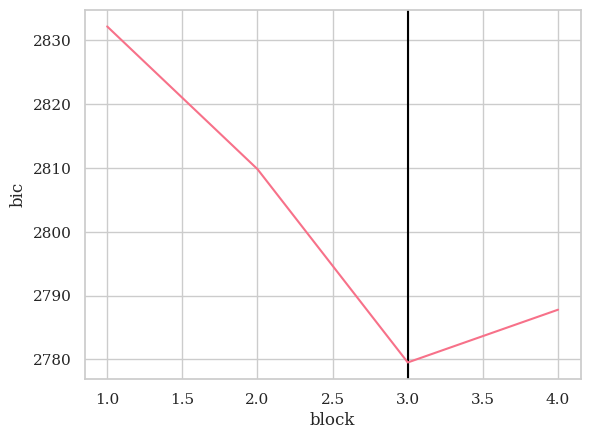

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

n_samples = X.shape[0]
plt.axvline(bttda.n_blocks_, color='black')
sns.lineplot(data=df, x='block', y=bttda.info_crit)


<Axes: xlabel='block', ylabel='mse'>

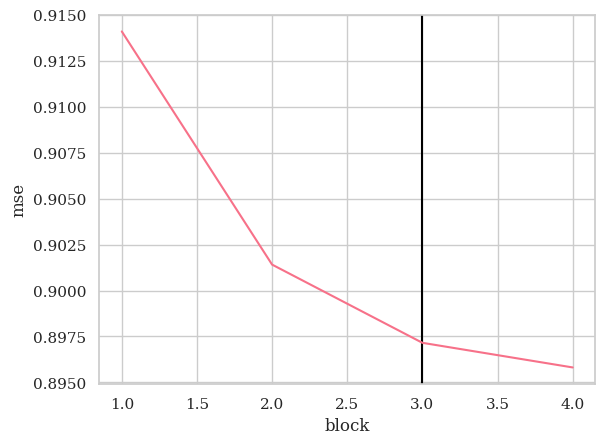

In [8]:
plt.axvline(bttda.n_blocks_, color='black')

sns.lineplot(data=df, x='block', y='mse')

In [9]:
Xt = bttda.transform(X)

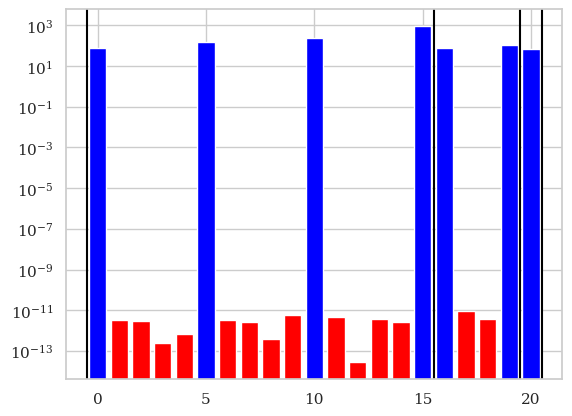

In [10]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)
fig, ax = plt.subplots(1,1)
sig_idc = p < (0.5/len(p))
plt.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
plt.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
plt.yscale('log')
n_params=0
plt.axvline(n_params-.5, color='black')
for b,block in enumerate(bttda.blocks_):
    n_params+=math.prod(block.rank_)
    plt.axvline(n_params-.5, color='black')

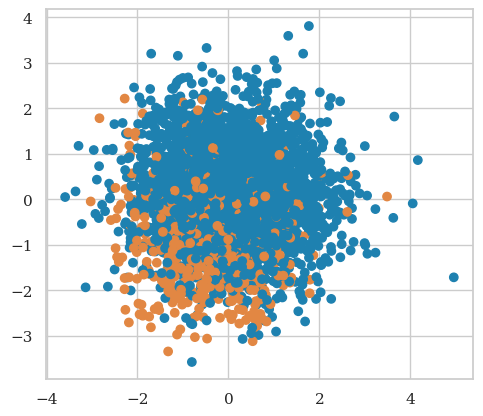

In [11]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')


In [12]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]), units=dict(eeg=None))
joint_args=dict(ts_args=ts_args)

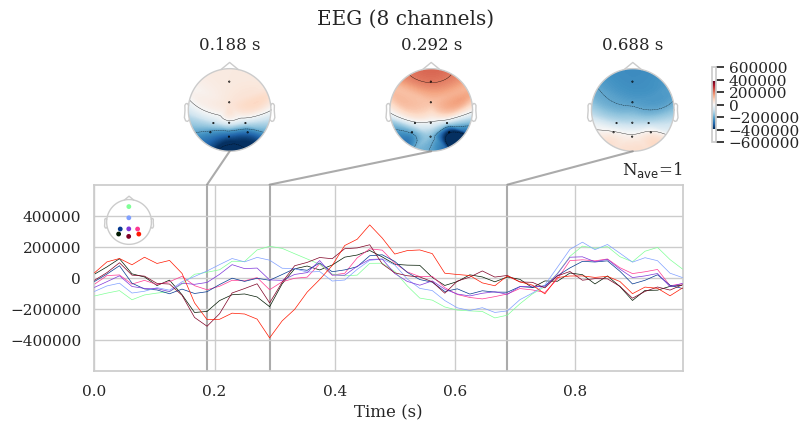

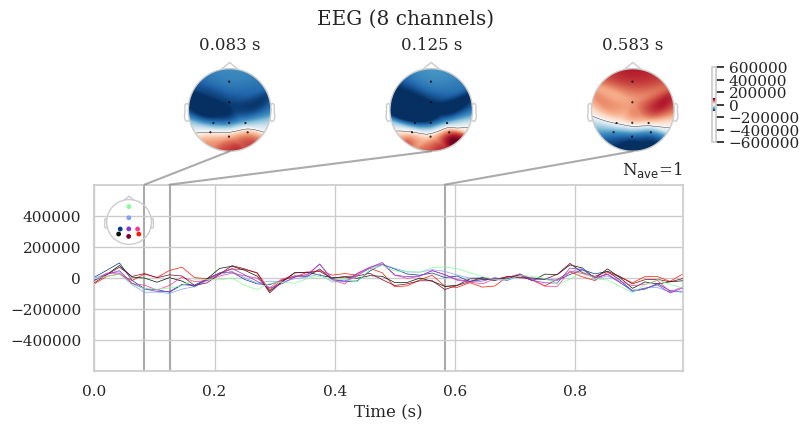

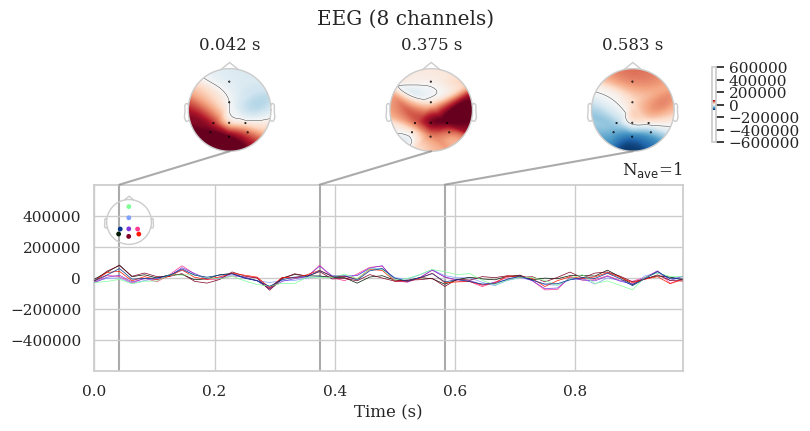

In [13]:
from mne import EvokedArray
for b in bttda.blocks_:
    means_rec = b.means_
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    contrast.plot_joint(**joint_args)

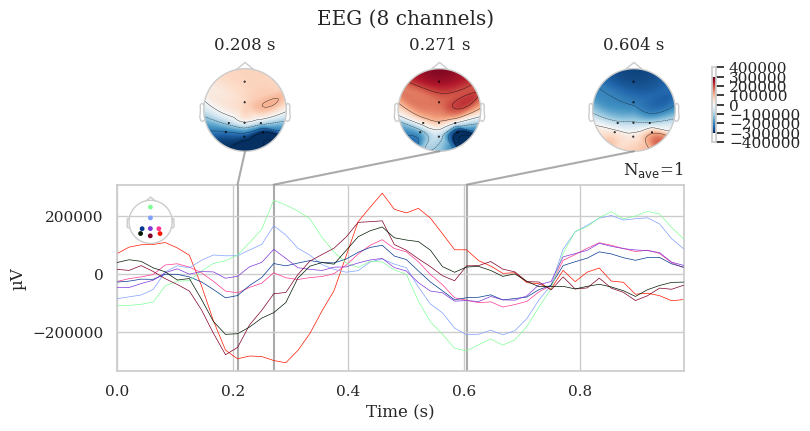

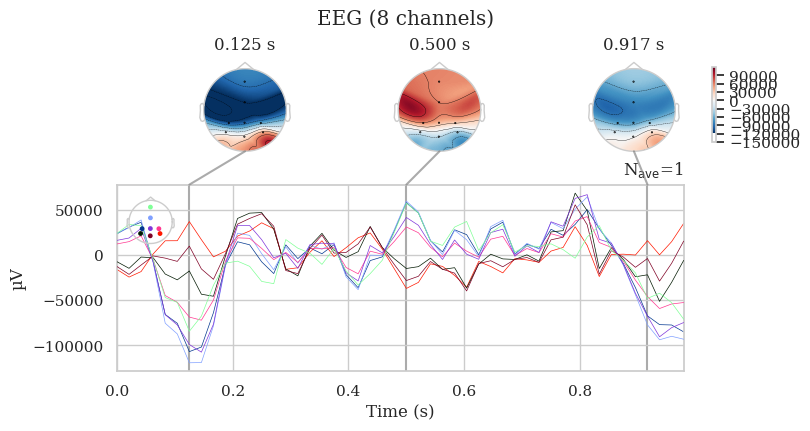

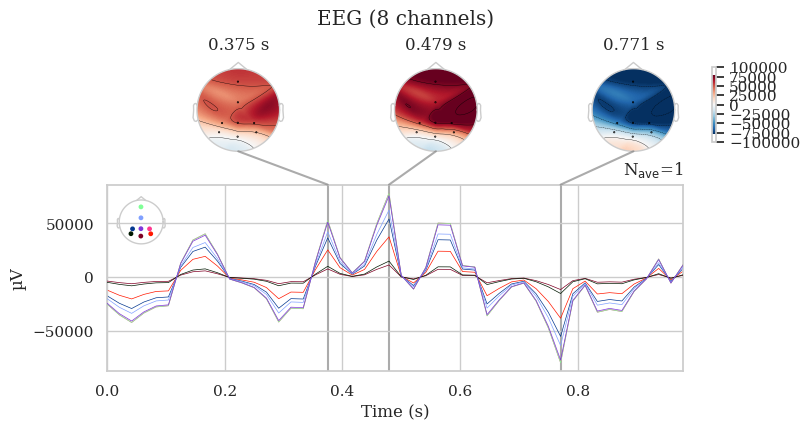

In [19]:
from mne import EvokedArray
for b in bttda.blocks_[:10]:
    means_rec = b.inv_transform(b.transform(b.means_))
    contrast = means_rec[1]-means_rec[0]
    contrast = EvokedArray(tl.to_numpy(contrast), epochs.info, epochs.tmin)
    #contrast.plot_joint(**joint_args)
    contrast.plot_joint()

In [15]:
X_rec = bttda.inv_transform(Xt)
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(X_rec)
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    #if len(evoked_rec.ch_names) > 1:
    #    evoked_rec.plot_joint(title=cls,**joint_args)
    #else:
    #    evoked_rec.plot(**ts_args)

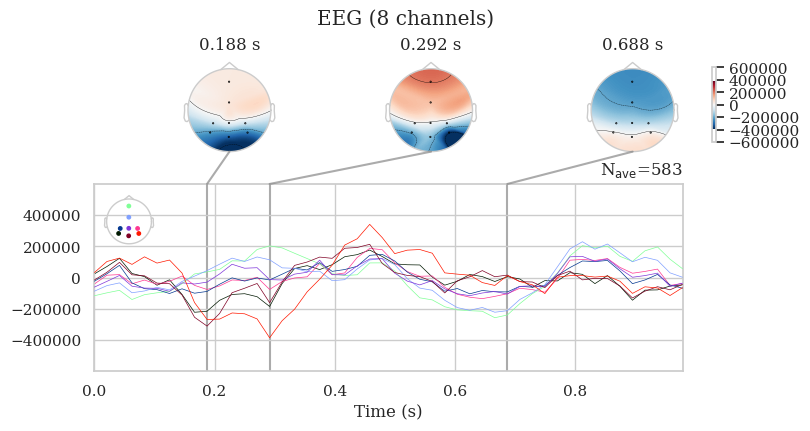

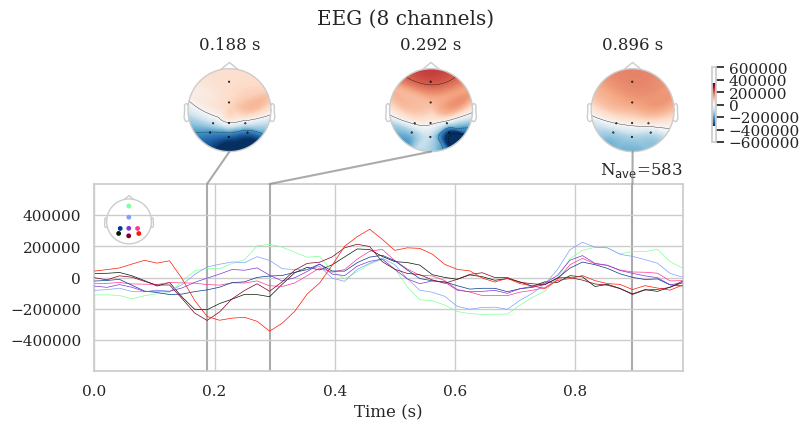

In [16]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


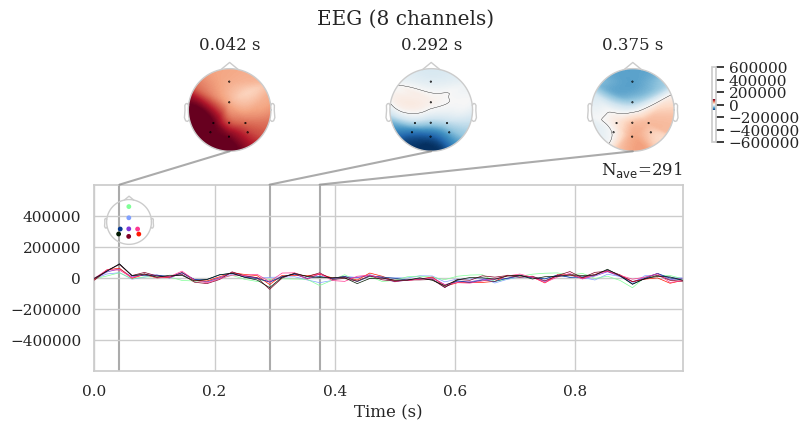

In [17]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)